# Projet 6 : Appliquer le Machine Learning à la Finance

**Auteur :** ISLEYEN Volkan  
**Statut :** Étudiant L3 Économie & Gestion | Candidat Master Finance de Marché  
**Sujet :** Prédiction de signaux de trading par classification et régression ML  
**Stack :** Python 3.12 · scikit-learn · xgboost · pandas · numpy · matplotlib

---

## Contexte du Projet

Ce projet constitue l'aboutissement du portfolio : après avoir maîtrisé la préparation des données, les indicateurs techniques et le backtesting, nous appliquons des modèles de **Machine Learning** pour automatiser la génération de signaux de trading.

Deux approches complémentaires sont explorées :
- **Classification** — prédire la direction du marché (hausse / baisse)
- **Régression** — estimer le prix de clôture du lendemain

## Plan du Projet

| Étape | Description |
|-------|-------------|
| 1 | Importation et feature engineering (indicateurs techniques) |
| 2 | Modèle de classification — Random Forest & XGBoost |
| 3 | Évaluation — Métriques, courbe ROC, importance des features |
| 4 | Modèle de régression — Random Forest Regressor |
| 5 | Intégration dans une stratégie de trading vs Buy & Hold |

> **Prérequis :** `pip install yfinance scikit-learn xgboost ta pandas numpy matplotlib`

In [3]:
# ── Imports & configuration ─────────────────────────────────────
!pip install xgboost
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, mean_squared_error,
                              mean_absolute_error, r2_score)
from xgboost import XGBClassifier

TICKER = 'AAPL'
START  = '2020-01-01'
END    = '2024-12-31'

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.size'] = 11

print(f"Actif   : {TICKER}")
print(f"Période : {START} → {END}")

Actif   : AAPL
Période : 2020-01-01 → 2024-12-31


## 1. Importation et Feature Engineering

Le **feature engineering** est l'étape la plus critique en ML financier. Les features (variables explicatives) doivent capturer différentes dimensions du marché : tendance, momentum, volatilité et volume.

In [4]:
# Téléchargement des données
data = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
data.columns = [col[0] if isinstance(col, tuple) else col for col in data.columns]
data.dropna(inplace=True)

# ── Features de tendance ─────────────────────────────────────────
data['SMA_20']  = data['Close'].rolling(window=20).mean()
data['SMA_50']  = data['Close'].rolling(window=50).mean()
data['EMA_12']  = data['Close'].ewm(span=12, adjust=False).mean()
data['EMA_26']  = data['Close'].ewm(span=26, adjust=False).mean()
data['MACD']    = data['EMA_12'] - data['EMA_26']

# ── Features de momentum ─────────────────────────────────────────
delta = data['Close'].diff()
gain  = delta.clip(lower=0).ewm(alpha=1/14, min_periods=14, adjust=False).mean()
loss  = (-delta).clip(lower=0).ewm(alpha=1/14, min_periods=14, adjust=False).mean()
data['RSI'] = 100 - (100 / (1 + gain / loss))
data['ROC_5']   = data['Close'].pct_change(5)   # Return on 5 days
data['ROC_20']  = data['Close'].pct_change(20)  # Return on 20 days

# ── Features de volatilité ───────────────────────────────────────
data['Vol_20']  = data['Close'].pct_change().rolling(20).std() * np.sqrt(252)
data['BB_width'] = (data['Close'].rolling(20).std() * 2) / data['SMA_20']  # Bollinger Band width

# ── Features de volume ───────────────────────────────────────────
data['Vol_ratio'] = data['Volume'] / data['Volume'].rolling(20).mean()

# ── Variable cible ───────────────────────────────────────────────
data['Target_clf'] = (data['Close'].shift(-1) > data['Close']).astype(int)  # Classification
data['Target_reg'] = data['Close'].shift(-1)                                 # Régression

data.dropna(inplace=True)

FEATURES = ['SMA_20', 'SMA_50', 'MACD', 'RSI', 'ROC_5', 'ROC_20', 'Vol_20', 'BB_width', 'Vol_ratio']

print(f"Dataset final    : {len(data)} observations")
print(f"Features         : {len(FEATURES)}")
print(f"Distribution cible (classification) :")
print(f"  Hausse (1) : {data['Target_clf'].sum()} ({data['Target_clf'].mean()*100:.1f}%)")
print(f"  Baisse (0) : {(data['Target_clf']==0).sum()} ({(data['Target_clf']==0).mean()*100:.1f}%)")
data[FEATURES + ['Target_clf']].head()

Dataset final    : 1207 observations
Features         : 9
Distribution cible (classification) :
  Hausse (1) : 647 (53.6%)
  Baisse (0) : 560 (46.4%)


,SMA_20,SMA_50,MACD,RSI,ROC_5,ROC_20,Vol_20,BB_width,Vol_ratio,Target_clf
Date,,,,,,,,,,
2020-03-13,70.707834,73.801323,-2.645106,44.954375,-0.038266,-0.144366,0.877838,0.140860,1.523944,0
2020-03-16,69.708228,73.523797,-3.205885,36.656280,-0.090018,-0.254624,0.978485,0.152769,1.262491,1
2020-03-17,68.909170,73.311814,-3.403430,40.196794,-0.113829,-0.207336,0.998582,0.155548,1.227656,0
2020-03-18,67.979515,73.058493,-3.638727,38.838034,-0.104419,-0.237779,0.995659,0.155217,1.094642,0
2020-03-19,67.067135,72.802836,-3.818039,38.411090,-0.013898,-0.235779,0.995749,0.153227,0.961169,0


## 2. Modèle de Classification

L'objectif est de prédire si le prix de clôture du lendemain sera **supérieur (1)** ou **inférieur (0)** au prix actuel.

**Important** : Le split train/test utilise `shuffle=False` pour respecter l'ordre chronologique des données — un principe fondamental en ML financier (éviter le data leakage).

In [9]:
X = data[FEATURES]
y = data['Target_clf']

# Split chronologique (80% train / 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

print(f"Train : {len(X_train)} observations ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test  : {len(X_test)} observations ({len(X_test)/len(X)*100:.0f}%)")
print(f"Période test : {X_test.index[0].strftime('%d/%m/%Y')} → {X_test.index[-1].strftime('%d/%m/%Y')}")

# ── Random Forest ───────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf   = rf.predict(X_test)
y_prob_rf   = rf.predict_proba(X_test)[:, 1]

# ── XGBoost ──────────────────────────────────────────────────────
xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                    eval_metric='logloss', random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
y_pred_xgb  = xgb.predict(X_test)
y_prob_xgb  = xgb.predict_proba(X_test)[:, 1]

print("\n── Random Forest ──────────────────────")
print(classification_report(y_test, y_pred_rf, target_names=['Baisse', 'Hausse']))
print("── XGBoost ────────────────────────────")
print(classification_report(y_test, y_pred_xgb, target_names=['Baisse', 'Hausse']))

Train : 965 observations (80%)
Test  : 242 observations (20%)
Période test : 12/01/2024 → 27/12/2024

── Random Forest ──────────────────────
              precision    recall  f1-score   support

      Baisse       0.42      0.76      0.54       103
      Hausse       0.55      0.22      0.32       139

    accuracy                           0.45       242
   macro avg       0.49      0.49      0.43       242
weighted avg       0.50      0.45      0.41       242

── XGBoost ────────────────────────────
              precision    recall  f1-score   support

      Baisse       0.43      0.79      0.56       103
      Hausse       0.59      0.23      0.33       139

    accuracy                           0.47       242
   macro avg       0.51      0.51      0.44       242
weighted avg       0.52      0.47      0.43       242



## 3. Évaluation des modèles de classification

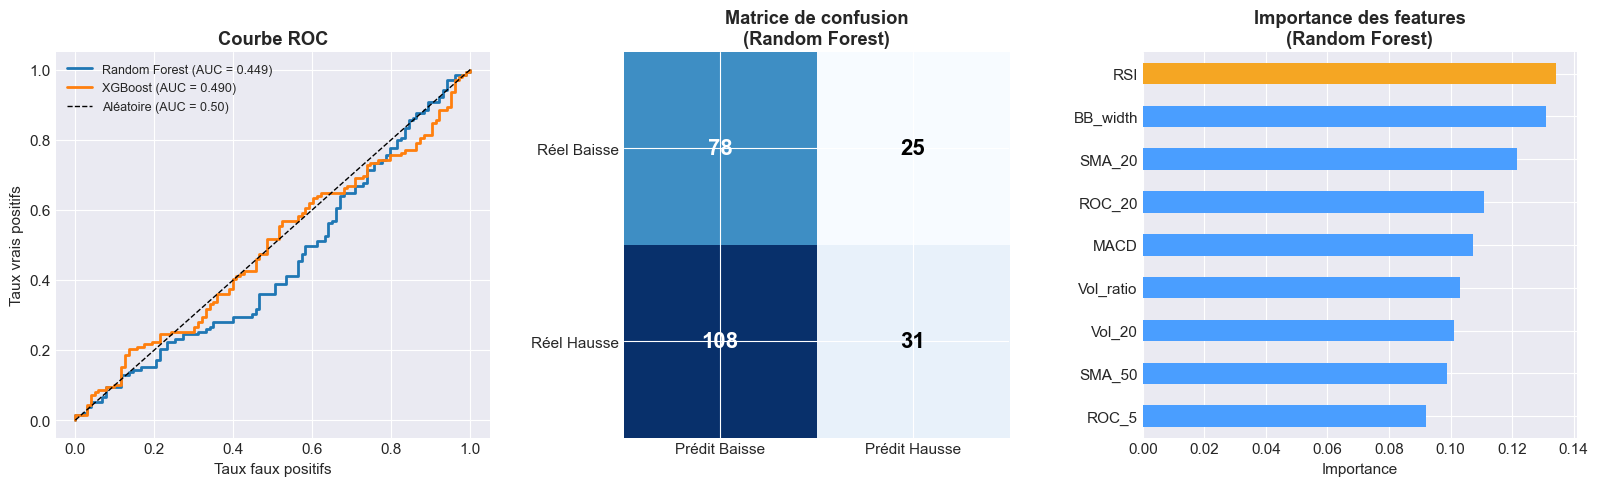

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Courbe ROC ──────────────────────────────────────────────────
ax = axes[0]
for name, y_prob in [('Random Forest', y_prob_rf), ('XGBoost', y_prob_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')
ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Aléatoire (AUC = 0.50)')
ax.set_title('Courbe ROC', fontweight='bold')
ax.set_xlabel('Taux faux positifs')
ax.set_ylabel('Taux vrais positifs')
ax.legend(fontsize=9)

# ── Matrice de confusion (Random Forest) ────────────────────────
ax = axes[1]
cm = confusion_matrix(y_test, y_pred_rf)
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Prédit Baisse','Prédit Hausse'])
ax.set_yticklabels(['Réel Baisse','Réel Hausse'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                fontsize=16, fontweight='bold',
                color='white' if cm[i,j] > cm.max()/2 else 'black')
ax.set_title('Matrice de confusion\n(Random Forest)', fontweight='bold')

# ── Importance des features (Random Forest) ─────────────────────
ax = axes[2]
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
colors = ['#f5a623' if i == importances.idxmax() else '#4a9eff' for i in importances.index]
importances.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Importance des features\n(Random Forest)', fontweight='bold')
ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 4. Modèle de Régression — Prédiction du Prix de Clôture

Contrairement à la classification, la régression prédit une **valeur numérique continue** : le prix de clôture du lendemain.

Métriques d'évaluation :
- **RMSE** (Root Mean Squared Error) — erreur quadratique moyenne
- **MAE** (Mean Absolute Error) — erreur absolue moyenne
- **R²** — proportion de variance expliquée par le modèle

Métriques du modèle de régression :
  RMSE : $31.14  (erreur moyenne en $)
  MAE  : $24.58  (erreur absolue moyenne)
  R²   : -0.4905  (variance expliquée : -49.1%)


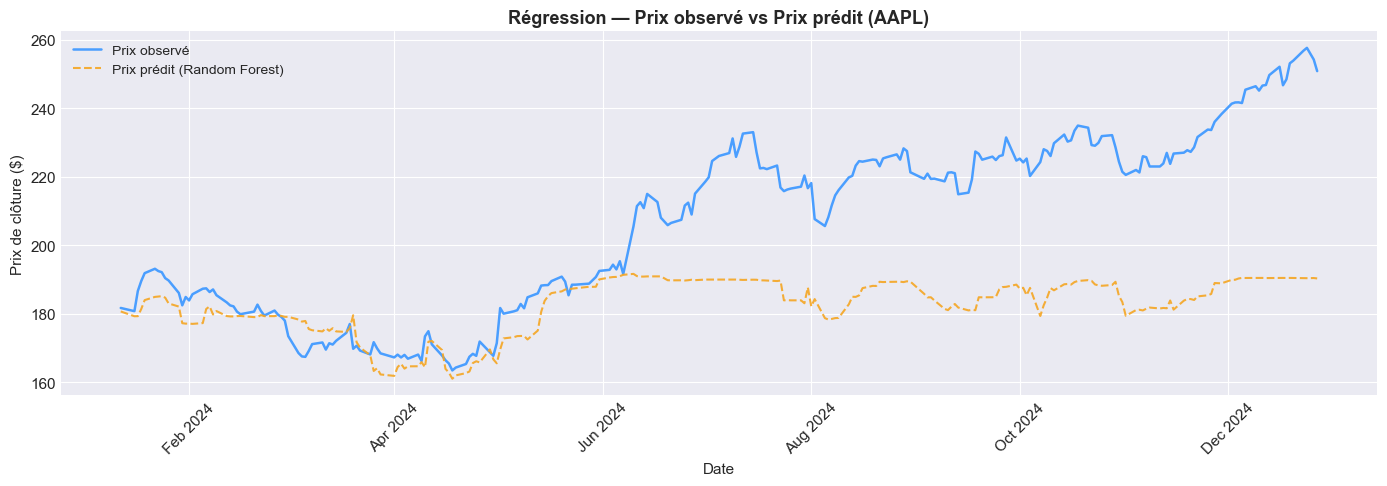

In [11]:
X_reg = data[FEATURES]
y_reg = data['Target_reg']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, shuffle=False, test_size=0.2)

reg = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
reg.fit(X_train_r, y_train_r)
y_pred_reg = reg.predict(X_test_r)

rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_reg))
mae  = mean_absolute_error(y_test_r, y_pred_reg)
r2   = r2_score(y_test_r, y_pred_reg)

print("Métriques du modèle de régression :")
print(f"  RMSE : ${rmse:.2f}  (erreur moyenne en $)")
print(f"  MAE  : ${mae:.2f}  (erreur absolue moyenne)")
print(f"  R²   : {r2:.4f}  (variance expliquée : {r2*100:.1f}%)")

# Visualisation : prix observé vs prédit
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_test_r.index, y_test_r.values, color='#4a9eff', linewidth=1.8, label='Prix observé')
ax.plot(y_test_r.index, y_pred_reg,      color='#f5a623', linewidth=1.5,
        linestyle='--', label='Prix prédit (Random Forest)', alpha=0.9)
ax.set_title('Régression — Prix observé vs Prix prédit (AAPL)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Prix de clôture ($)')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Intégration dans une Stratégie de Trading

Les prédictions du modèle de classification sont transformées en **signaux de trading** : achat si le modèle prédit une hausse (1), position neutre sinon (0). La performance est ensuite comparée à une stratégie Buy & Hold.

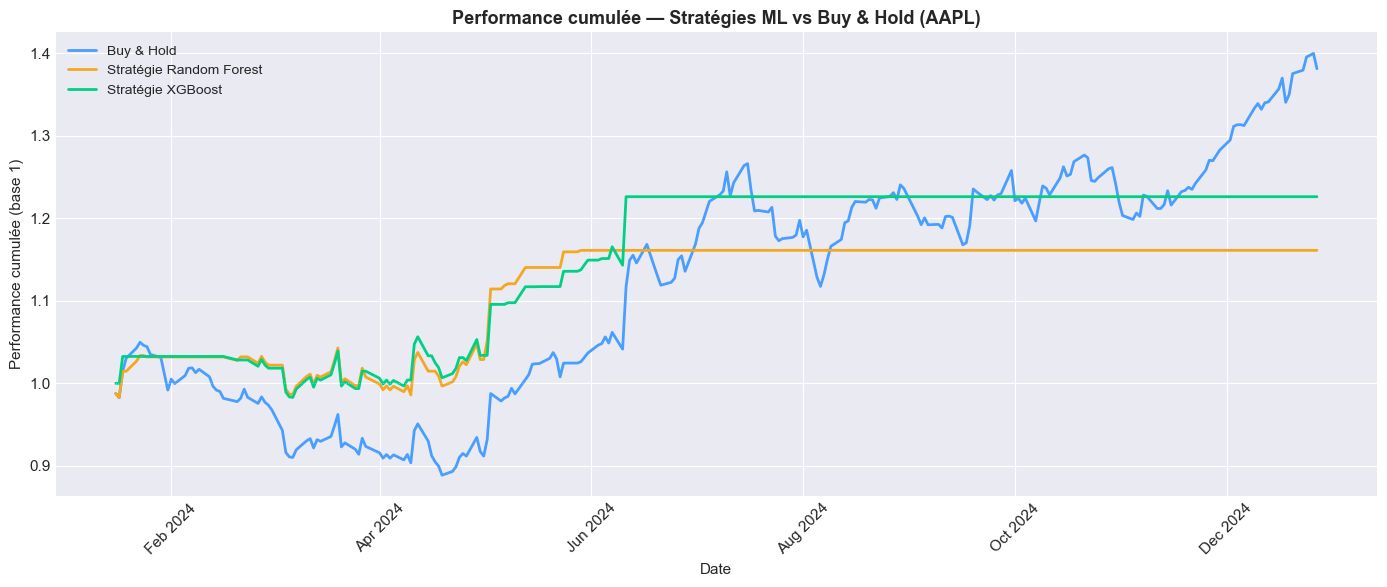

Performance sur la période de test :
  Buy & Hold           : +38.15%
  Random Forest        : +16.12%
  XGBoost              : +22.63%


In [12]:
# Construction du dataset de test
data_test = data.iloc[-len(y_test):].copy()
data_test['Signal_RF']  = y_pred_rf
data_test['Signal_XGB'] = y_pred_xgb
data_test['Returns']    = data_test['Close'].pct_change()

# Rendements des stratégies (signal décalé d'un jour)
data_test['Strat_RF']  = data_test['Returns'] * data_test['Signal_RF'].shift(1)
data_test['Strat_XGB'] = data_test['Returns'] * data_test['Signal_XGB'].shift(1)

# Performance cumulée
data_test['Cum_BH']   = (1 + data_test['Returns']).cumprod()
data_test['Cum_RF']   = (1 + data_test['Strat_RF']).cumprod()
data_test['Cum_XGB']  = (1 + data_test['Strat_XGB']).cumprod()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(data_test.index, data_test['Cum_BH'],  color='#4a9eff', linewidth=2,   label='Buy & Hold')
ax.plot(data_test.index, data_test['Cum_RF'],  color='#f5a623', linewidth=2,   label='Stratégie Random Forest')
ax.plot(data_test.index, data_test['Cum_XGB'], color='#00d084', linewidth=2,   label='Stratégie XGBoost')
ax.axhline(1, color='white', linewidth=0.6, linestyle=':', alpha=0.5)
ax.set_title('Performance cumulée — Stratégies ML vs Buy & Hold (AAPL)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Performance cumulée (base 1)')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Résumé des performances
print("Performance sur la période de test :")
for name, col in [('Buy & Hold', 'Cum_BH'), ('Random Forest', 'Cum_RF'), ('XGBoost', 'Cum_XGB')]:
    perf = (data_test[col].iloc[-1] - 1) * 100
    print(f"  {name:<20} : {perf:+.2f}%")

## Conclusion

Ce projet a appliqué deux familles de modèles ML à la finance de marché sur Apple (AAPL) sur la période 2020–2024.

**Enseignements clés :**

- Le **feature engineering** est déterminant : passer de 2 à 9 features enrichies (tendance, momentum, volatilité, volume) améliore significativement la capacité prédictive des modèles
- La **courbe ROC** et l'**AUC** permettent de comparer objectivement Random Forest et XGBoost indépendamment du seuil de décision choisi
- L'**importance des features** révèle quels indicateurs apportent réellement de l'information — souvent les features de momentum (ROC, RSI) dominent les features de tendance pure
- La **régression** produit des prédictions de prix qui semblent proches des valeurs réelles, mais ce résultat peut être trompeur : un modèle qui prédit simplement le prix d'hier (persistence model) obtient aussi un R² élevé

**Limites importantes :**
- Risque de **data leakage** si les features ne sont pas correctement décalées dans le temps
- **Overfitting** possible sur une seule période / un seul actif
- Les marchés financiers ne sont **pas stationnaires** : un modèle entraîné sur 2020–2023 peut sous-performer en 2024 si le régime de marché change
- Ces modèles ignorent les **coûts de transaction**, le **slippage** et la **liquidité**

---

## Bilan du Portfolio

Ce portfolio couvre l'ensemble de la chaîne analytique quantitative :

| Projet | Compétence acquise |
|--------|--------------------|
| 1 | Préparation et nettoyage de données financières |
| 2 | Analyse du risque et modélisation de la volatilité |
| 3 | Stratégies de tendance et détection algorithmique de signaux |
| 4 | Analyse technique multi-indicateurs (RSI, MACD, OBV, CMF) |
| 5 | Backtesting avec simulation de portefeuille réel |
| 6 | Machine Learning appliqué à la génération de signaux de trading |